# 📊 Análise de vendas com Python e SQL
Projeto de análise de dados desenvolvido em Python, utilizando Pandas, Matplotlib e SQL para explorar dados, calcular indicadores de faturamento e gerar insights para tomada de decisão.


## 🔧 Tecnologias utilizadas
- Python
- Pandas
- Matplotlib
- SQLite
- SQL
- Google Colab

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Carregamento e exploração dos dados
Nesta etapa, os dados, de vendas são carregados em um DataFrame utilizando a biblioteca Pandas.

In [ ]:
dados = {
    'produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor'],
    'categoria': ['Eletrônicos','Eletrônicos','Eletrônicos','Eletrônicos'],
    'quantidade': [2,10,5,3],
    'preco': [3500, 80, 150, 490],
    'cidade': ['São Paulo', 'Rio De Janeiro', 'São Paulo', 'Curitiba']
}

df = pd.DataFrame(dados)

df

,produto,categoria,quantidade,preco,cidade
0,Notebook,Eletrônicos,2,3500,São Paulo
1,Mouse,Eletrônicos,10,80,Rio De Janeiro
2,Teclado,Eletrônicos,5,150,São Paulo
3,Monitor,Eletrônicos,3,490,Curitiba


# Tratamento dos dados
Nesta etapa, é calculado o faturamento de cada venda a partir da quantidade de produtos vendidos e do preço unitário.

In [ ]:
df['faturamento'] = df['quantidade'] * df['preco']



In [ ]:
df

,produto,categoria,quantidade,preco,cidade,faturamento
0,Notebook,Eletrônicos,2,3500,São Paulo,7000
1,Mouse,Eletrônicos,10,80,Rio De Janeiro,800
2,Teclado,Eletrônicos,5,150,São Paulo,750
3,Monitor,Eletrônicos,3,490,Curitiba,1470


## 💰 Faturamento por produto
Nesta análise, o faturamento total é agrupado por produto para identificar quais produtos geram maior receita.

In [ ]:
faturamento_produto = df.groupby('produto')['faturamento'].sum()
faturamento_produto

,faturamento
produto,
Monitor,1470
Mouse,800
Notebook,7000
Teclado,750


In [ ]:
faturamento_produto.sort_values(ascending=False)

,faturamento
produto,
Notebook,7000
Monitor,1470
Mouse,800
Teclado,750


In [ ]:
faturamento_cidade = df.groupby('cidade')['faturamento'].sum()
faturamento_cidade

,faturamento
cidade,
Curitiba,1470
Rio De Janeiro,800
São Paulo,7750


In [ ]:
faturamento_cidade.sort_values(ascending=False)

,faturamento
cidade,
São Paulo,7750
Curitiba,1470
Rio De Janeiro,800


##📍 Faturamento por cidade
Nesta análise, o faturamento é agrupado por cidade para identificar quais localidades apresentam maior desempenho em vendas.


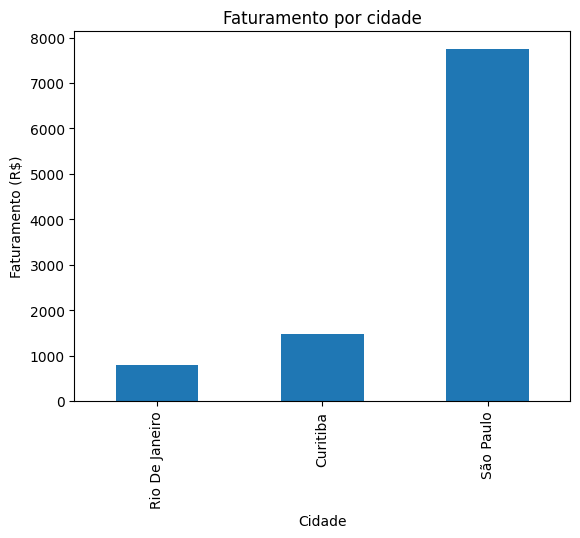

In [ ]:
faturamento_cidade.sort_values().plot(kind='bar')

plt.title('Faturamento por cidade')
plt.xlabel('Cidade')
plt.ylabel('Faturamento (R$)')

plt.show()

In [ ]:
faturamento_cidade.sort_values(ascending=False)

,faturamento
cidade,
São Paulo,7750
Curitiba,1470
Rio De Janeiro,800


In [ ]:
quantidade_produto = df.groupby('produto')['quantidade'].sum()
quantidade_produto

,quantidade
produto,
Monitor,3
Mouse,10
Notebook,2
Teclado,5


In [ ]:
quantidade_produto.sort_values(ascending=False)

,quantidade
produto,
Mouse,10
Teclado,5
Monitor,3
Notebook,2


## 🛍️ Faturamento por produto
Nesta análise, o faturamento é agrupado por produto para identificar quais produtos geram maior receita.

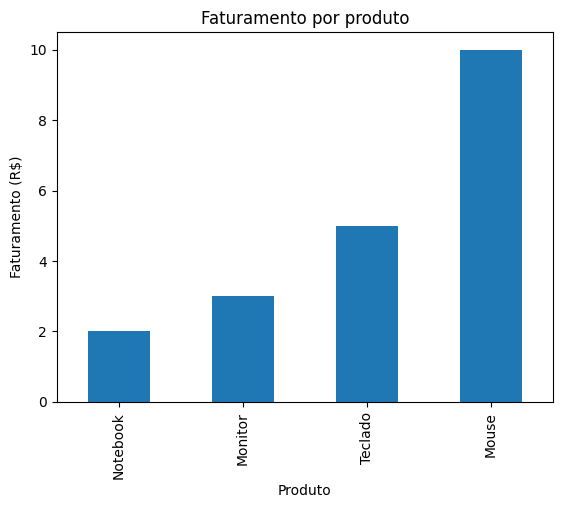

In [ ]:
quantidade_produto.sort_values().plot(kind='bar')

plt.title('Faturamento por produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento (R$)')

plt.show()

## 📦 Quantidade de produtos vendidos
Nesta análise, é apresentada a quantidade total de unidades vendidas por produto.

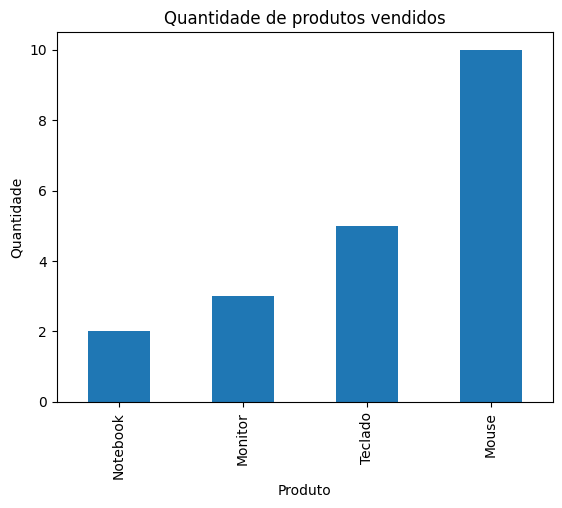

In [ ]:
quantidade_produto = df.groupby('produto')['quantidade'].sum()
quantidade_produto.sort_values().plot(kind='bar')

plt.title('Quantidade de produtos vendidos')
plt.xlabel('Produto')
plt.ylabel('Quantidade')

plt.show()

In [ ]:
quantidade_produto = df.groupby('produto')['quantidade'].sum()
quantidade_produto.sort_values(ascending=False)

,quantidade
produto,
Mouse,10
Teclado,5
Monitor,3
Notebook,2


## 📆 Análise de vendas por data
Nesta etapa, as datas das vendas são convertidas para o formato adequado e utilizadas para analisar a evolução do faturamento ao longo do período.

In [ ]:
df['data'] = [
    '2026-08-01',
    '2026-08-03',
    '2026-08-05',
    '2026-08-07'
]

df


,produto,categoria,quantidade,preco,cidade,faturamento,data
0,Notebook,Eletrônicos,2,3500,São Paulo,7000,2026-08-01
1,Mouse,Eletrônicos,10,80,Rio De Janeiro,800,2026-08-03
2,Teclado,Eletrônicos,5,150,São Paulo,750,2026-08-05
3,Monitor,Eletrônicos,3,490,Curitiba,1470,2026-08-07


In [ ]:
df['data'] = pd.to_datetime(df['data'])


In [ ]:
faturamento_data = df.groupby('data')['faturamento'].sum()

faturamento_data

,faturamento
data,
2026-08-01,7000
2026-08-03,800
2026-08-05,750
2026-08-07,1470


# 📉 Evolução do faturamento
O gráfico abaixo apresenta a evolução do faturamento ao longo das datas analisadas.

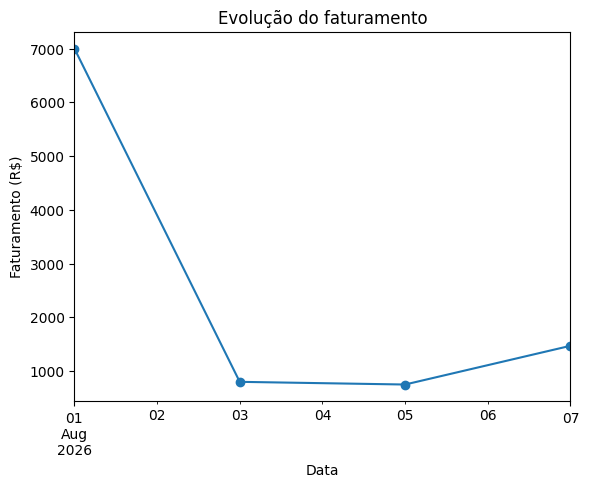

In [ ]:
faturamento_data.plot(kind='line', marker='o')

plt.title('Evolução do faturamento')
plt.xlabel('Data')
plt.ylabel('Faturamento (R$)')

plt.show()

## 🏆 Melhor dia de vendas
A análise abaixo identifica a data que apresentou o maior faturamento.

In [ ]:
melhor_dia = faturamento_data.idxmax()
maior_faturamento = faturamento_data.max()

print('Melhor dia:', melhor_dia.strftime('%d/%m/%Y'))
print(f'Maior faturamento: R$ {maior_faturamento:,.2f}')

Melhor dia: 01/08/2026
Maior faturamento: R$ 7,000.00


In [ ]:
resumo = {
    'faturamento_total': df['faturamento'].sum(),
    'produto_maior_faturamento': faturamento_produto.idxmax(),
    'cidade_maior_faturamento': faturamento_cidade.idxmax(),
    'mehor_dia': faturamento_data.idxmax(),
    'maior_faturamento_diario': faturamento_data.max()
}

resumo

{'faturamento_total': np.int64(10020),
 'produto_maior_faturamento': 'Notebook',
 'cidade_maior_faturamento': 'São Paulo',
 'mehor_dia': Timestamp('2026-08-01 00:00:00'),
 'maior_faturamento_diario': 7000}

In [ ]:
melhor_dia = faturamento_data.idxmax()
resumo['melhor_dia'] = melhor_dia
print('Melhor dia:', resumo['melhor_dia'])

Melhor dia: 2026-08-01 00:00:00


## 📊 Resumo dos indicadores
Nesta etapa, os principais indicadores da análise são consolidados para facilitar a interpretação dos resultados.

In [ ]:
resumo = {
    'faturamento_total': df['faturamento'].sum(),
    'produto_maior_faturamento': faturamento_produto.idxmax(),
    "cidade_maior_faturamento": faturamento_cidade.idxmax(),
    'melhor_dia': faturamento_data.idxmax(),
    'maior_faturamento_diario': faturamento_data.max()
}

In [ ]:
relatorio = f"""
Faturamento total: R${resumo['faturamento_total']:.2f}
Produto com maior faturamento: {resumo['produto_maior_faturamento']}
Cidade com maior faturamento: {resumo['cidade_maior_faturamento']}
Melhor dia: {resumo['melhor_dia'].strftime('%d/%m/%Y')}
Maior faturamento diário: R${resumo['maior_faturamento_diario']:.2f}
"""
print(relatorio)


Faturamento total: R$10020.00
Produto com maior faturamento: Notebook
Cidade com maior faturamento: São Paulo
Melhor dia: 01/08/2026
Maior faturamento diário: R$7000.00



## 💡Principais insights
A análise dos dados permitiu  identificar os principais destaques de faturamento, cidade e data.
Os resultados podem ser utilizados para apoiar decisões relacionadas á concentração de vendas, desempenho dos produtos e oportunidades de crescimento.

In [ ]:
print(f"💰 Faturamento total: R$ {resumo['faturamento_total']:,.2f}")
print(f"🏆 Produto líder em faturamento: {resumo['produto_maior_faturamento']}")
print(f"📍 Cidade líder em faturamento: {resumo['cidade_maior_faturamento']}")
print(f"📅 Melhor dia: {resumo['melhor_dia'].strftime('%d/%m/%Y')}")
print(f"📈 Maior faturamento diário: R$ {resumo['maior_faturamento_diario']:,.2f}")

💰 Faturamento total: R$ 10,020.00
🏆 Produto líder em faturamento: Notebook
📍 Cidade líder em faturamento: São Paulo
📅 Melhor dia: 01/08/2026
📈 Maior faturamento diário: R$ 7,000.00


# 🗄️ Análise utilizando SQL
Nesta etapa, os dados do DataFrame são armazenados em um banco SQLite e consultados utilizando SQL.

In [ ]:
import sqlite3
conexao = sqlite3.connect('vendas.db')
df.to_sql('vendas', conexao, if_exists='replace', index=False)
print('Tabela vendas criadas com sucesso!')

Tabela vendas criadas com sucesso!


## 🔎 Visualização dos dados com SQL
Primeiramente, podemos consultar os registros armazenados na tabela 'vendas'.


In [ ]:
consulta = """
SELECT *
FROM vendas
"""
resultado_sql = pd.read_sql(consulta, conexao)

resultado_sql

,produto,categoria,quantidade,preco,cidade,faturamento,data
0,Notebook,Eletrônicos,2,3500,São Paulo,7000,2026-08-01 00:00:00
1,Mouse,Eletrônicos,10,80,Rio De Janeiro,800,2026-08-03 00:00:00
2,Teclado,Eletrônicos,5,150,São Paulo,750,2026-08-05 00:00:00
3,Monitor,Eletrônicos,3,490,Curitiba,1470,2026-08-07 00:00:00


## 📍 Faturamento por cidade
A consulta abaixo agrupa as vendas por cidade e calcula o faturamento total de cada localidade.

In [ ]:
consulta = """
SELECT cidade, SUM(faturamento) AS faturamento_total
FROM vendas
GROUP BY cidade
ORDER BY faturamento_total DESC;
"""

resultado_sql = pd.read_sql_query(consulta, conexao)
resultado_sql

,cidade,faturamento_total
0,São Paulo,7750
1,Curitiba,1470
2,Rio De Janeiro,800


In [ ]:
conexao.close()

## 🤖 Interpretação dos resultados com IA
A integração com IA foi explorada como uma etapa complementar para transformar os indicadores calculados em uma interpretação de negócio.


A análise com IA foi considerada como uma etapa complementar do projeto. Os indicadores gerados com Python e SQL podem ser enviados a um modelo de linguagem para obtenção de uma interpretação automatizada e recomendações de negócio.

Neste notebook, os principais insights são apresentados diretamente a partir dos dados analisados, garantindo que o projeto possa ser executado sem dependência de uma API externa.

## 🎯 Conclusão
A análise permitiu identificar os principais indicadores de desempenho das vendas, incluindo faturamento total, desempenho por produto, desempenho por cidade e evolução das vendas ao longo do tempo.

O projeto também demonstrou a utilização de Python, Pandas, visualizações, SQL e SQLite para transformar dados de vendas em informações úteis para análise e tomada de decisão.

Como evolução futura, o projeto poderia incorporar uma base de dados maior, dashboards interativos e integração com modelos de IA para geração automatizada de insights.